In [ ]:
!pip install segmentation-models-pytorch albumentations scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 6.6 MB/s eta 0:00:00


In [ ]:
import os

image_dir = "/content/train/images"
label_dir = "/content/train/labels"
mask_dir  = "/content/train/masks"

os.makedirs(mask_dir, exist_ok=True)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
print(os.listdir("/content/drive/MyDrive"))

['20240721_150655.jpg', '20240721_150722.jpg', 'Document from Preesha Tandon', 'Colab Notebooks', 'Sih', 'Preesha_Tandon_Resume_Final (2).pdf', 'Preesha_Tandon_Resume_Final (1).pdf', 'Preesha_Tandon_Resume_Final.pdf', 'ENG23EC0074_PREESHA TANDON.pdf', 'runs', 'Railway Crack Detection.v2i.yolov5pytorch.zip']


In [ ]:
!unzip -o "/content/drive/MyDrive/Railway Crack Detection.v2i.yolov5pytorch.zip" -d /content/

Archive:  /content/drive/MyDrive/Railway Crack Detection.v2i.yolov5pytorch.zip
 extracting: /content/valid/images/Image-242_jpg.rf.4a4f79a2a1cf27ec03cf2629bdf7da6b.jpg  
 extracting: /content/valid/images/Image-576_jpg.rf.f5cc76ff705e59c9caa7815c9c337eba.jpg  
 extracting: /content/valid/images/Image-240_jpg.rf.df3ed59f3b3d9a4e5fbe8070e039a631.jpg  
 extracting: /content/valid/images/Image-239_jpg.rf.b767f915e986efef6fafb0b0a0a23cfc.jpg  
 extracting: /content/train/images/Image-684_jpg.rf.1235f88b6097d6467cd73edb701567fe.jpg  
 extracting: /content/valid/images/Image-243_jpg.rf.7ddcd4852b6ef3fe307e8af791f63d04.jpg  
 extracting: /content/train/images/Image-798_jpg.rf.9a0a4b266a5e46dce8257b9c8bc23e79.jpg  
 extracting: /content/valid/images/Image-241_jpg.rf.a248ed1c06a699311d783f1d0a1c6625.jpg  
 extracting: /content/train/images/Image-685_jpg.rf.7fab9b26da202ab02578eddf0535a26f.jpg  
 extracting: /content/test/images/Image-128_jpg.rf.52b6d117c864dca65a97dd0160e21064.jpg  
 extracting:

In [ ]:
import cv2
import numpy as np

for img_name in os.listdir(image_dir):
    if not img_name.lower().endswith(('.jpg','.png','.jpeg')):
        continue

    img_path   = os.path.join(image_dir, img_name)
    label_path = os.path.join(label_dir, img_name.replace('.jpg','.txt').replace('.png','.txt'))

    img = cv2.imread(img_path)
    h, w = img.shape[:2]

    mask = np.zeros((h, w), dtype=np.uint8)

    if os.path.exists(label_path):
        with open(label_path) as f:
            for line in f:
                cls, x, y, bw, bh = map(float, line.split())
                x1 = int((x - bw/2) * w)
                y1 = int((y - bh/2) * h)
                x2 = int((x + bw/2) * w)
                y2 = int((y + bh/2) * h)
                mask[y1:y2, x1:x2] = 255

    # optional refinement
    mask = cv2.erode(mask, np.ones((5,5), np.uint8))

    cv2.imwrite(os.path.join(mask_dir, img_name.replace('.jpg','.png')), mask)

print("✅ Masks created")

✅ Masks created


In [ ]:
import albumentations as A
import torch
from torch.utils.data import Dataset, DataLoader

transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.Rotate(limit=20, p=0.5),
    A.RandomBrightnessContrast(p=0.2),
])

class CrackDataset(Dataset):
    def __init__(self, img_dir, mask_dir):
        self.img_dir = img_dir
        self.mask_dir = mask_dir
        self.images = os.listdir(img_dir)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_name = self.images[idx]

        img  = cv2.imread(os.path.join(self.img_dir, img_name))
        img  = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        mask = cv2.imread(os.path.join(self.mask_dir, img_name.replace(".jpg",".png")), 0)

        aug  = transform(image=img, mask=mask)
        img, mask = aug['image'], aug['mask']

        img  = cv2.resize(img, (256,256)) / 255.0
        mask = cv2.resize(mask, (256,256))
        mask = (mask > 0).astype(np.float32)

        img  = torch.tensor(img).permute(2,0,1).float()
        mask = torch.tensor(mask).unsqueeze(0).float()

        return img, mask

In [ ]:
dataset = CrackDataset(image_dir, mask_dir)
dataloader = DataLoader(dataset, batch_size=8, shuffle=True)

In [ ]:
import segmentation_models_pytorch as smp

model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1,
)

device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

Unet(
  (encoder): ResNetEncoder(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track

In [ ]:
import torch.nn as nn

bce = nn.BCEWithLogitsLoss()
dice = smp.losses.DiceLoss(mode='binary')

def loss_fn(pred, target):
    return bce(pred, target) + dice(pred, target)

In [ ]:
import torch

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

In [ ]:
for epoch in range(20):
    model.train()
    total_loss = 0

    for imgs, masks in dataloader:
        imgs, masks = imgs.to(device), masks.to(device)

        preds = model(imgs)
        loss = loss_fn(preds, masks)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss/len(dataloader)}")

Epoch 1, Loss: 1.0780476329257949
Epoch 2, Loss: 0.808369992446507
Epoch 3, Loss: 0.6557521276758531
Epoch 4, Loss: 0.5505399535958169
Epoch 5, Loss: 0.4675717596654539
Epoch 6, Loss: 0.44246926725891883
Epoch 7, Loss: 0.3829179419963448
Epoch 8, Loss: 0.3672984078710462
Epoch 9, Loss: 0.32659437289699117
Epoch 10, Loss: 0.30543566634686886
Epoch 11, Loss: 0.2816975651454533
Epoch 12, Loss: 0.2919698111222359
Epoch 13, Loss: 0.27810837612046624
Epoch 14, Loss: 0.2704851069016221
Epoch 15, Loss: 0.20840085769999664
Epoch 16, Loss: 0.20942597043673689
Epoch 17, Loss: 0.2428948950834971
Epoch 18, Loss: 0.1921033924483836
Epoch 19, Loss: 0.2263996718382394
Epoch 20, Loss: 0.16933121660210712


In [ ]:
def iou_score(pred, mask):
    inter = (pred * mask).sum()
    union = pred.sum() + mask.sum() - inter
    return (inter+1e-6)/(union+1e-6)

def dice_score(pred, mask):
    inter = (pred * mask).sum()
    return (2*inter+1e-6)/(pred.sum()+mask.sum()+1e-6)

In [ ]:
def pixel_accuracy(pred, mask):
    pred = pred.flatten()
    mask = mask.flatten()
    return (pred == mask).sum() / len(pred)

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

In [ ]:
model.eval()

ious, dices, accs = [], [], []
y_true, y_pred = [], []

for i in range(200):
    img, mask = dataset[i]

    with torch.no_grad():
        pred = model(img.unsqueeze(0).to(device))[0][0].cpu().numpy()

    pred = (pred > 0.5).astype(int)
    mask = mask[0].numpy().astype(int)

    # segmentation metrics
    ious.append(iou_score(pred, mask))
    dices.append(dice_score(pred, mask))
    accs.append(pixel_accuracy(pred, mask))

    # classification metrics
    y_true.extend(mask.flatten())
    y_pred.extend(pred.flatten())

print("IoU:", sum(ious)/len(ious))
print("Dice:", sum(dices)/len(dices))
print("Accuracy:", sum(accs)/len(accs))

print("Precision:", precision_score(y_true, y_pred))
print("Recall:", recall_score(y_true, y_pred))
print("F1-score:", f1_score(y_true, y_pred))

IoU: 0.8393966581592717
Dice: 0.8844099315953762
Accuracy: 0.9788042449951172
Precision: 0.9554551296539125
Recall: 0.9051414227972573
F1-score: 0.9296179919655925


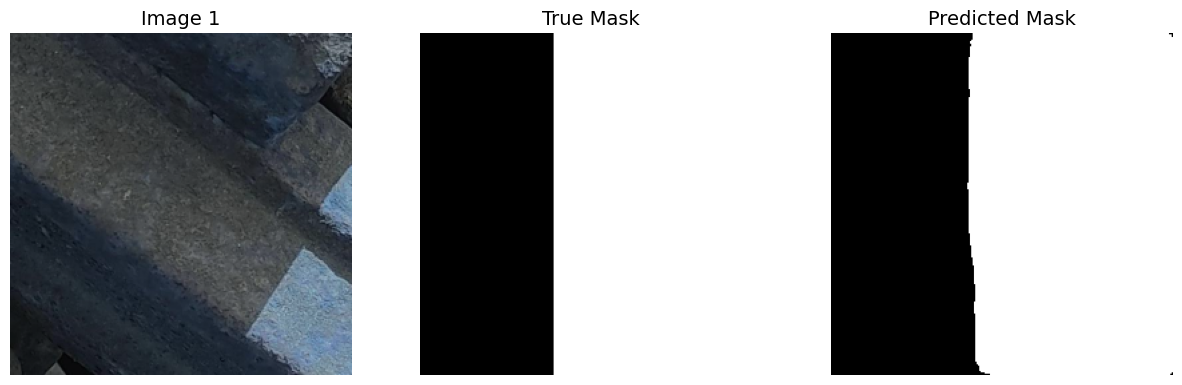

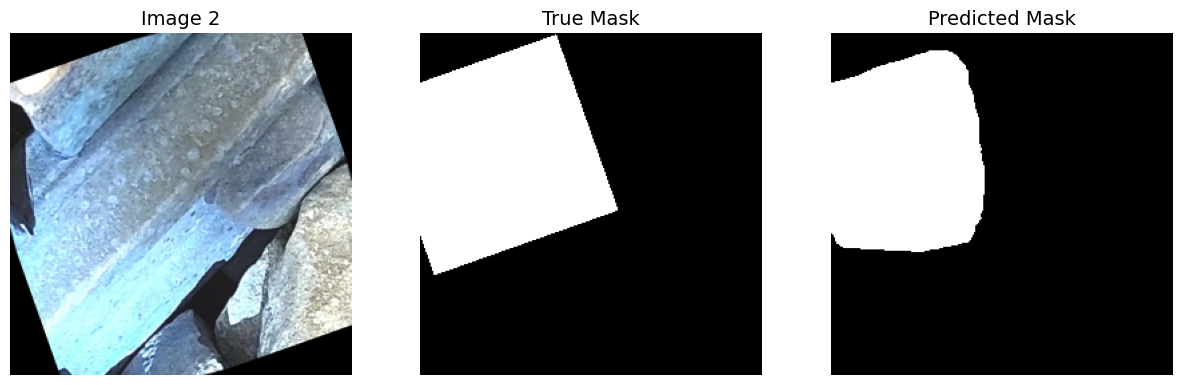

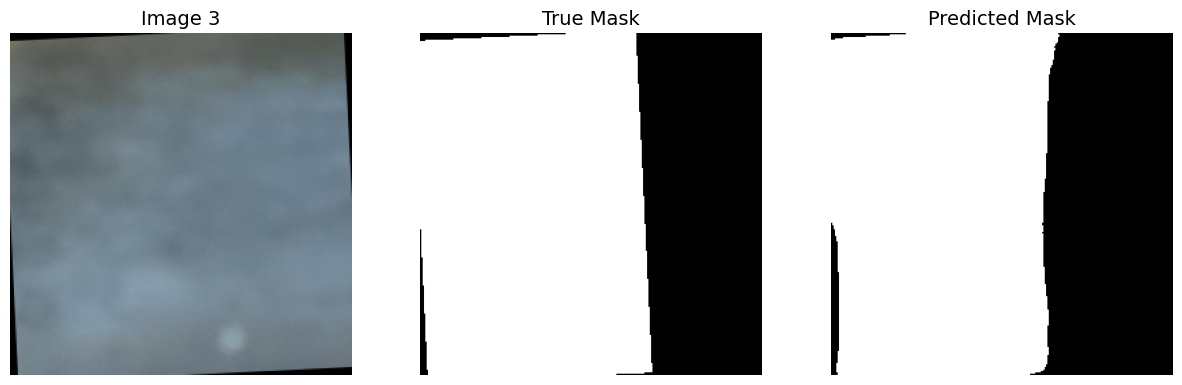

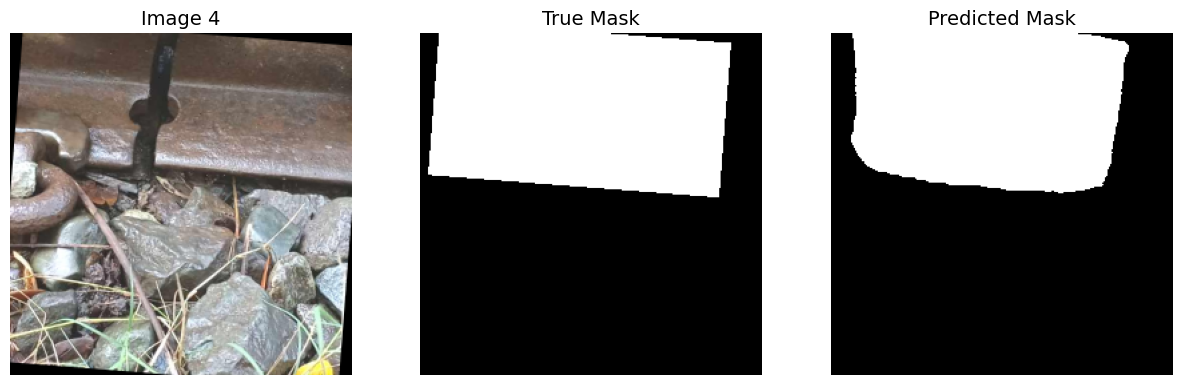

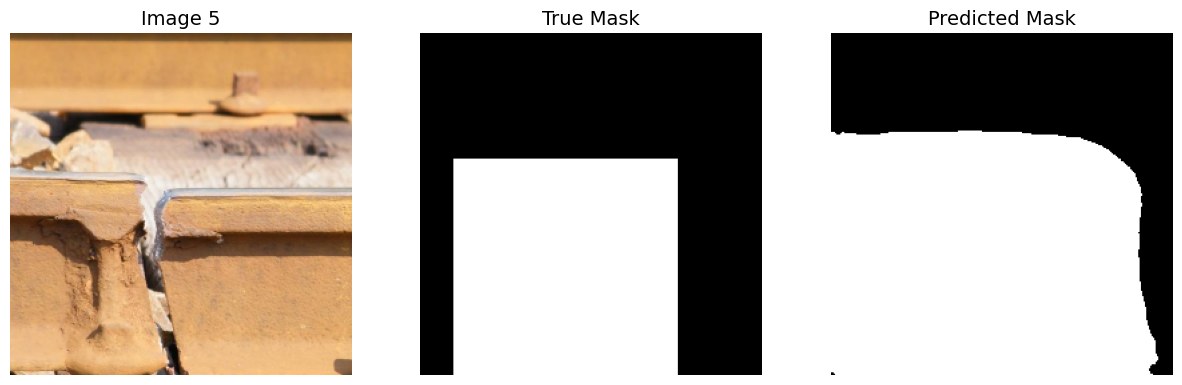

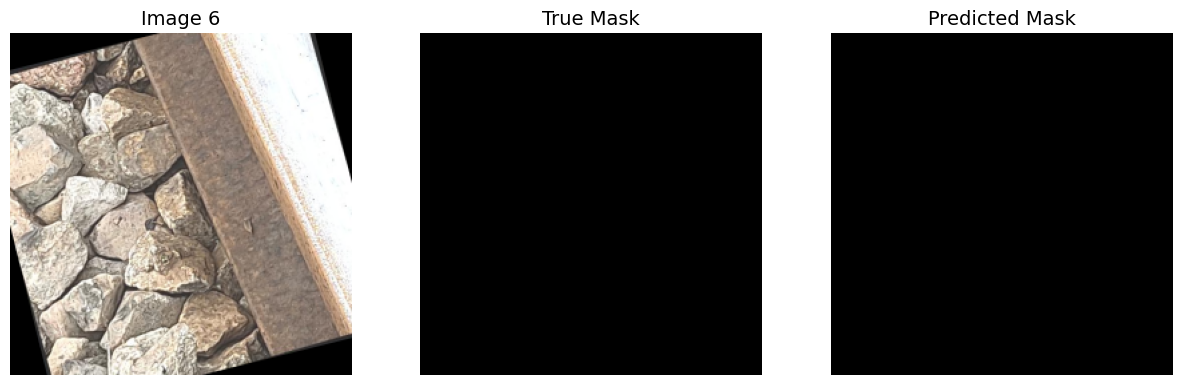

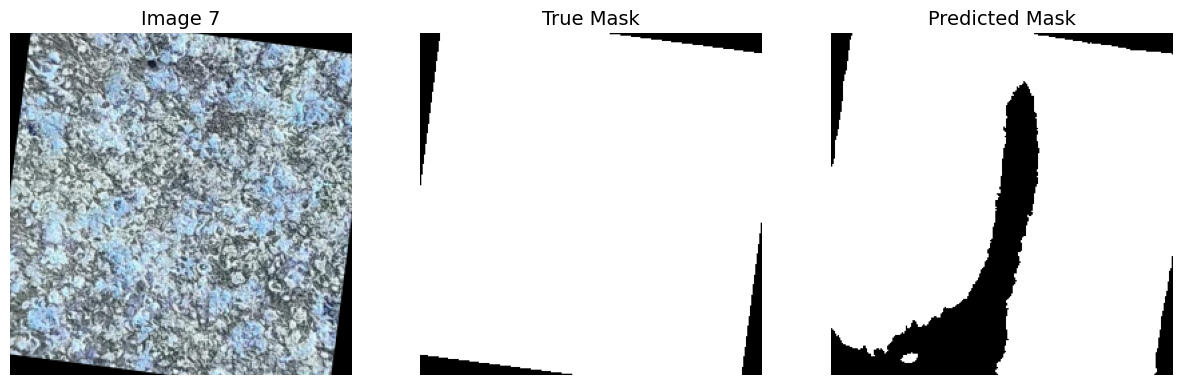

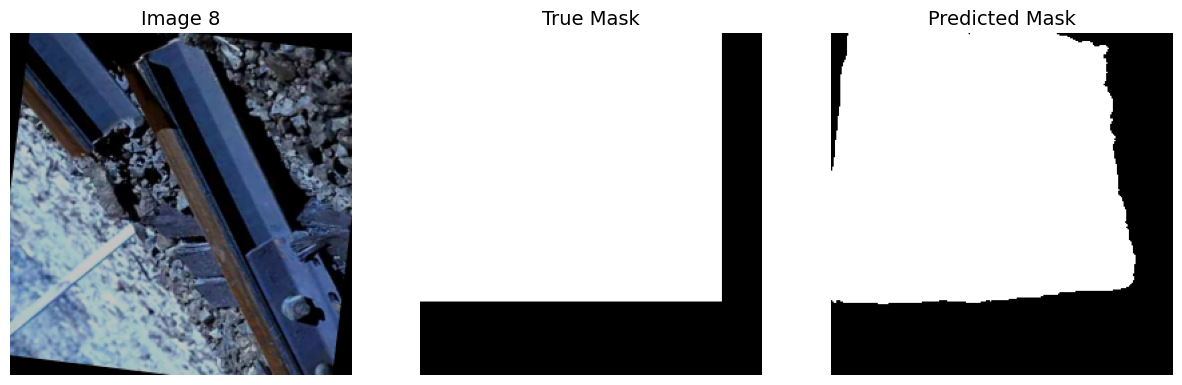

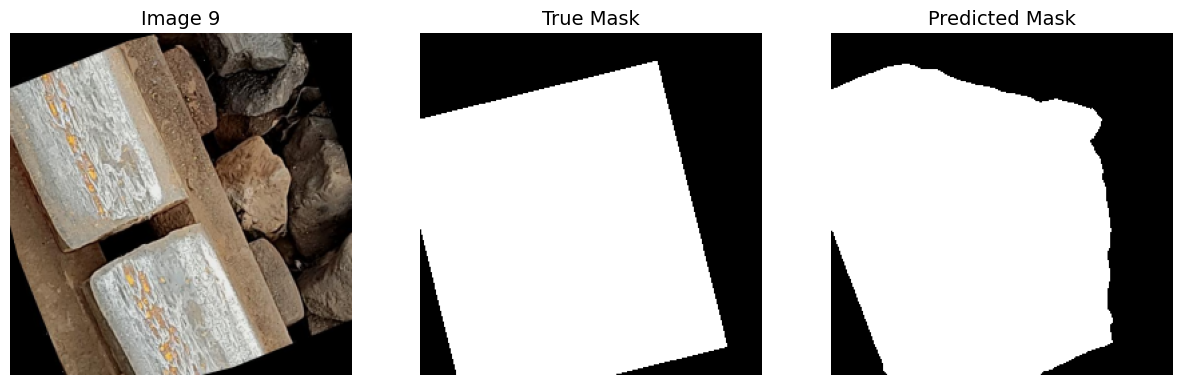

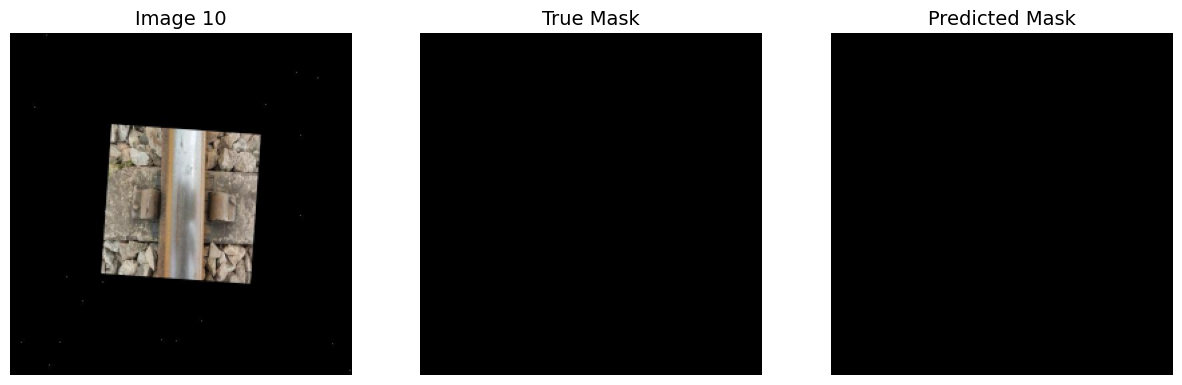

In [ ]:
import matplotlib.pyplot as plt
import random

model.eval()

num_samples = 10   # increase this for more outputs

for i in range(num_samples):
    idx = random.randint(0, len(dataset)-1)
    img, mask = dataset[idx]

    with torch.no_grad():
        pred = model(img.unsqueeze(0).to(device))[0][0].cpu().numpy()

    pred = (pred > 0.5).astype(float)

    plt.figure(figsize=(15,5))

    # Original Image
    plt.subplot(1,3,1)
    plt.imshow(img.permute(1,2,0))
    plt.title(f"Image {i+1}", fontsize=14)
    plt.axis("off")

    # True Mask
    plt.subplot(1,3,2)
    plt.imshow(mask[0], cmap='gray')
    plt.title("True Mask", fontsize=14)
    plt.axis("off")

    # Predicted Mask
    plt.subplot(1,3,3)
    plt.imshow(pred, cmap='gray')
    plt.title("Predicted Mask", fontsize=14)
    plt.axis("off")

    plt.show()

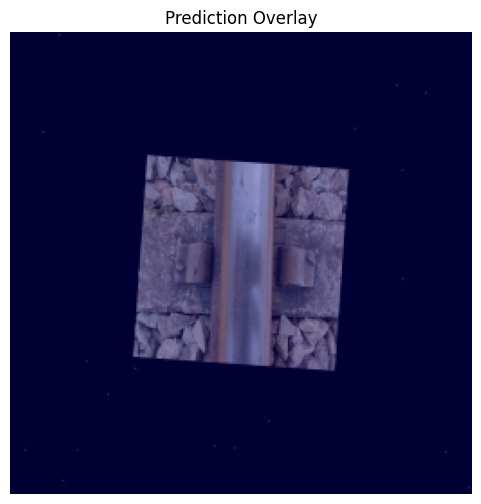

In [ ]:
plt.figure(figsize=(6,6))
plt.imshow(img.permute(1,2,0))
plt.imshow(pred, cmap='jet', alpha=0.4)
plt.title("Prediction Overlay")
plt.axis("off")
plt.show()

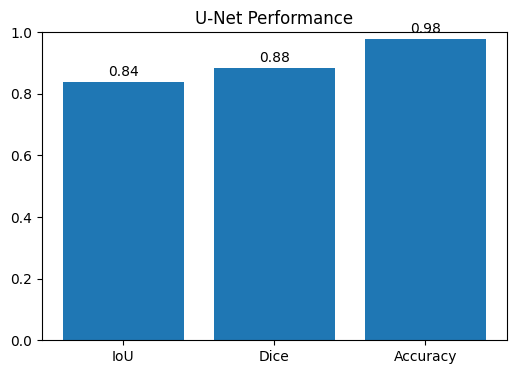

In [ ]:
avg_iou = sum(ious)/len(ious)
avg_dice = sum(dices)/len(dices)
avg_acc = sum(accs)/len(accs)

import matplotlib.pyplot as plt

metrics = ['IoU', 'Dice', 'Accuracy']
values = [avg_iou, avg_dice, avg_acc]

plt.figure(figsize=(6,4))
plt.bar(metrics, values)
plt.ylim(0,1)
plt.title("U-Net Performance")

for i, v in enumerate(values):
    plt.text(i, v + 0.02, f"{v:.2f}", ha='center')

plt.show()

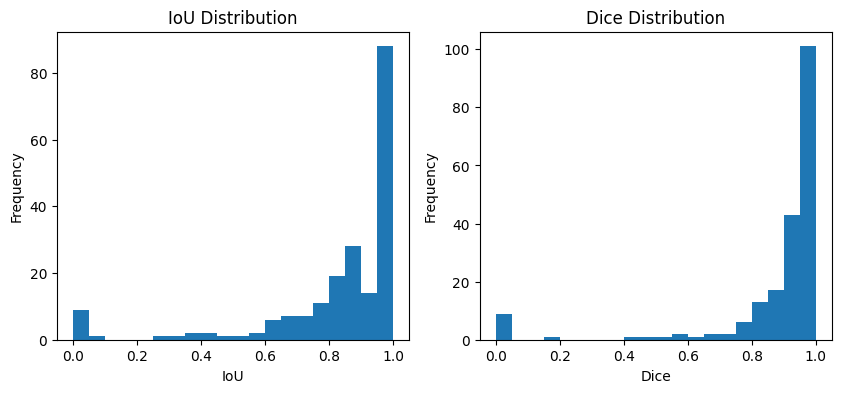

In [ ]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.hist(ious, bins=20)
plt.title("IoU Distribution")
plt.xlabel("IoU")
plt.ylabel("Frequency")

plt.subplot(1,2,2)
plt.hist(dices, bins=20)
plt.title("Dice Distribution")
plt.xlabel("Dice")
plt.ylabel("Frequency")

plt.show()

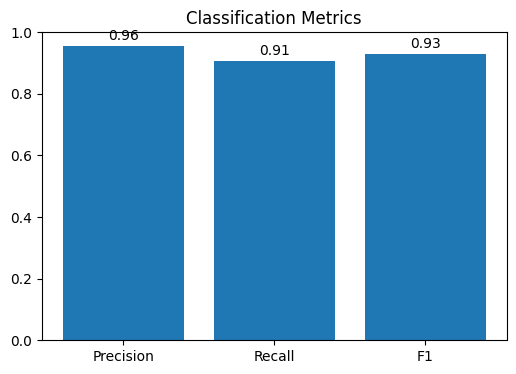

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

metrics = ['Precision', 'Recall', 'F1']
values = [precision, recall, f1]

plt.figure(figsize=(6,4))
plt.bar(metrics, values)
plt.ylim(0,1)
plt.title("Classification Metrics")

for i, v in enumerate(values):
    plt.text(i, v + 0.02, f"{v:.2f}", ha='center')

plt.show()

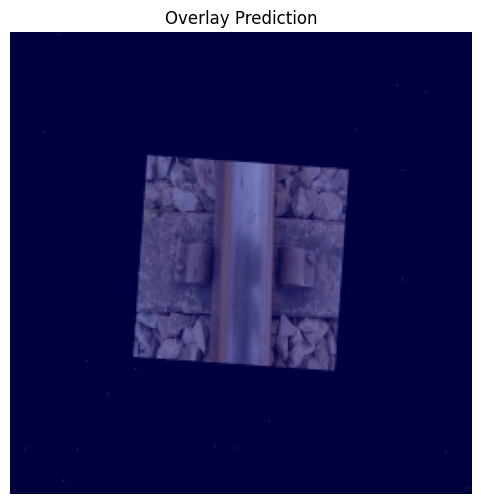

In [ ]:
plt.figure(figsize=(6,6))
plt.imshow(img.permute(1,2,0))
plt.imshow(pred, cmap='jet', alpha=0.5)
plt.title("Overlay Prediction")
plt.axis("off")
plt.show()

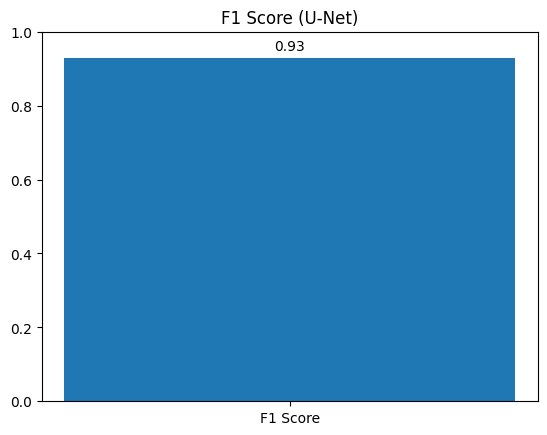

In [ ]:
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt

f1 = f1_score(y_true, y_pred)

plt.figure()
plt.bar(['F1 Score'], [f1])
plt.ylim(0,1)
plt.title("F1 Score (U-Net)")

plt.text(0, f1 + 0.02, f"{f1:.2f}", ha='center')

plt.show()

In [ ]:
from sklearn.metrics import f1_score

f1_scores = []

model.eval()

for i in range(200):
    img, mask = dataset[i]

    with torch.no_grad():
        pred = model(img.unsqueeze(0).to(device))[0][0].cpu().numpy()

    pred = (pred > 0.5).astype(int)
    mask = mask[0].numpy().astype(int)

    f1 = f1_score(mask.flatten(), pred.flatten())
    f1_scores.append(f1)

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metr

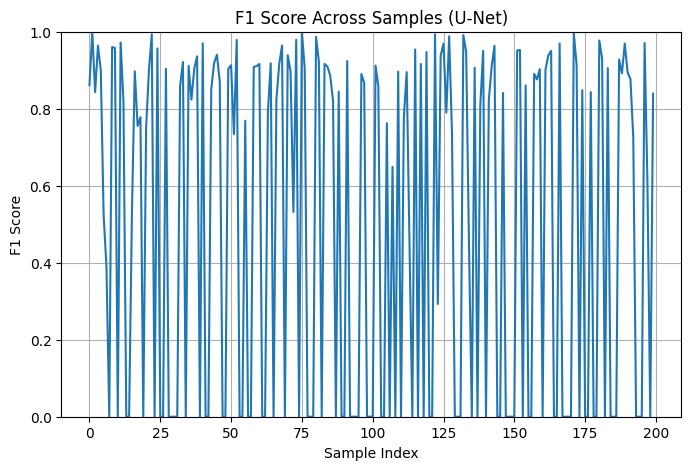

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(f1_scores)
plt.title("F1 Score Across Samples (U-Net)")
plt.xlabel("Sample Index")
plt.ylabel("F1 Score")
plt.ylim(0,1)

plt.grid(True)

plt.show()

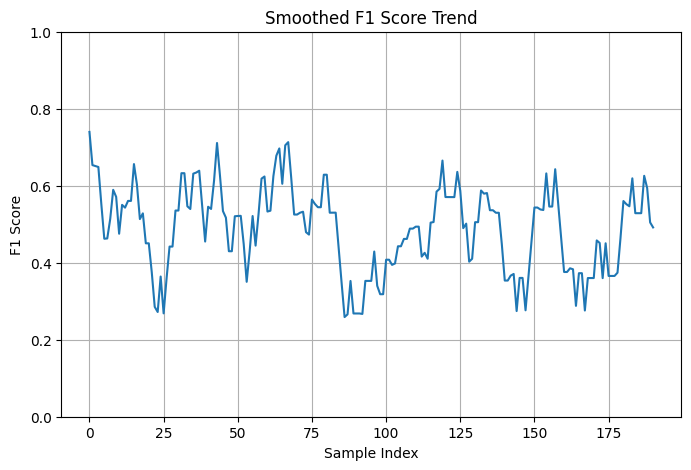

In [ ]:
import numpy as np

# moving average for smooth curve
window = 10
smooth_f1 = np.convolve(f1_scores, np.ones(window)/window, mode='valid')

plt.figure(figsize=(8,5))

plt.plot(smooth_f1)
plt.title("Smoothed F1 Score Trend")
plt.xlabel("Sample Index")
plt.ylabel("F1 Score")
plt.ylim(0,1)

plt.grid(True)

plt.show()

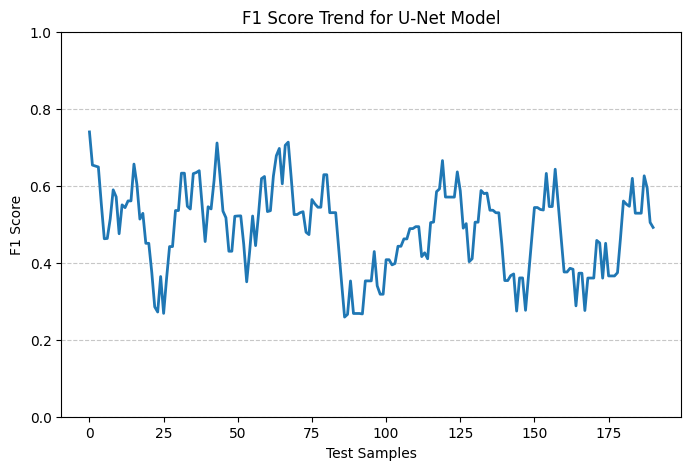

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(smooth_f1, linewidth=2)
plt.title("F1 Score Trend for U-Net Model")
plt.xlabel("Test Samples")
plt.ylabel("F1 Score")
plt.ylim(0,1)

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()